# Analyzing Smaller Regions

This notebook applies trained PINN-MSCNN models to smaller spatial regions extracted from the MODEST Hinode/SP dataset. This allows for:
- Focused analysis on specific features (sunspots, plage, quiet sun)
- Reduced computational requirements
- Detailed pixel-by-pixel comparison
- Region-specific error analysis

The analysis uses the same comprehensive tools from `utils/analysis_functions.py` as notebook 8.

## 0. Prerequisites

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
import astropy.units as u
from pathlib import Path
import sys
from scipy.stats import pearsonr
import pandas as pd
from typing import Dict, Tuple, Optional

# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer
from utils.analysis_functions import ModestAnalysis

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Base images save path
images_base_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images")

analysis = ModestAnalysis()

print("✓ All imports successful")

✓ All imports successful


## 1. Define Region Boundaries

Define the spatial boundaries for the region you want to analyze.

In [2]:
# Define region boundaries (adjust these values as needed)
# Example 1: Small region around a sunspot (100x100 pixels)
#y_start = 200
#y_end = 300
#x_start = 300
#x_end = 400
#images_save_path = images_base_path / "modest_analysis/cut_region_sunspot"

# Example 2: Plage region (150x150 pixels)
y_start = 0
y_end = 100
x_start = 400
x_end = 600
images_save_path = images_base_path / "modest_analysis/cut_region_plage"


# Example 3: Quiet sun region (80x80 pixels)
# y_start = 50
# y_end = 130
# x_start = 600
# x_end = 680
# images_save_path = images_base_path / "modest_analysis/cut_region_quiet_sun"

print(f"Region boundaries:")
print(f"  Y: {y_start} to {y_end} (height: {y_end - y_start} pixels)")
print(f"  X: {x_start} to {x_end} (width: {x_end - x_start} pixels)")
print(f"  Total pixels: {(y_end - y_start) * (x_end - x_start):,}")

images_save_path.mkdir(parents=True, exist_ok=True)

Region boundaries:
  Y: 0 to 100 (height: 100 pixels)
  X: 400 to 600 (width: 200 pixels)
  Total pixels: 20,000


## 2. Load MODEST Data and Extract Region

In [3]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

# Load full MODEST dataset
modest = ModestData()
modest.load_all(apply_mask=False)
print("✓ Full MODEST data loaded")
print(f"  Full continuum shape: {modest.continuum.shape}")

# Extract the specified region
region_data = modest.extract_region(y_start, y_end, x_start, x_end)
print(f"\n✓ Region extracted successfully")
print(f"  Region continuum shape: {region_data['continuum'].shape}")
print(f"  Region Stokes I shape: {region_data['obs_stokes']['I'].shape}")

modest_logtau = [-2.0, -0.8, 0.0]

✓ Full MODEST data loaded
  Full continuum shape: (390, 858)

✓ Region extracted successfully
  Region continuum shape: (100, 200)
  Region Stokes I shape: (100, 200, 112)


In [4]:
# Load normalizers
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

# Normalize Stokes data for the region
normalized_stokes = stokes_normalizer.transform(region_data['obs_stokes'])
print("✓ Normalizers loaded and region Stokes data normalized")

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json
✓ Normalizers loaded and region Stokes data normalized


## 3. Visualize the Extracted Region

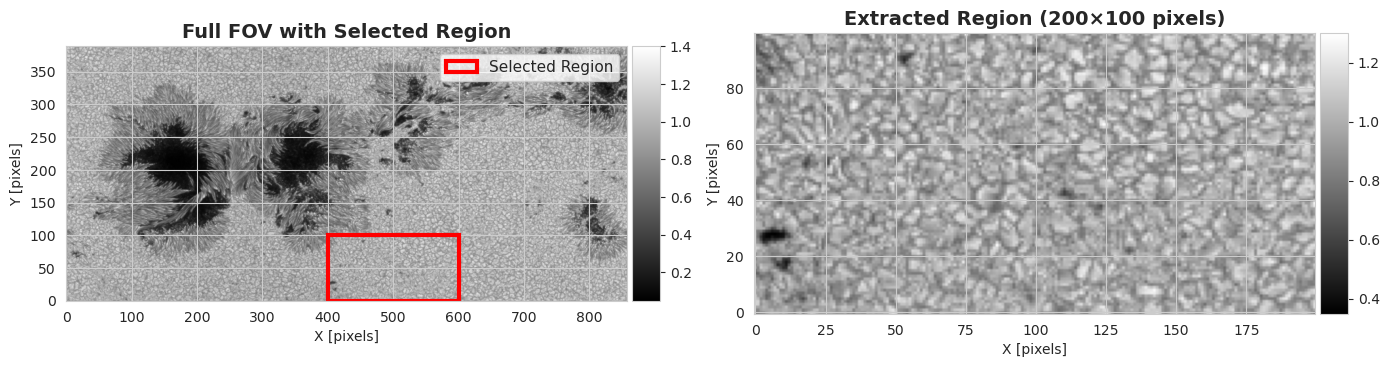

Region intensity range: 0.3 - 1.3


<Figure size 640x480 with 0 Axes>

In [5]:
# Plot the continuum of the extracted region
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full FOV with region highlighted
im0 = axes[0].imshow(modest.continuum, cmap='gray', origin='lower')
axes[0].set_title("Full FOV with Selected Region", fontsize=14, fontweight='bold')
axes[0].set_xlabel("X [pixels]")
axes[0].set_ylabel("Y [pixels]")

# Draw rectangle around selected region
from matplotlib.patches import Rectangle
rect = Rectangle((x_start, y_start), x_end - x_start, y_end - y_start,
                linewidth=3, edgecolor='red', facecolor='none', label='Selected Region')
axes[0].add_patch(rect)
axes[0].legend(fontsize=11)

divider = make_axes_locatable(axes[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im0, cax=cax)

# Extracted region continuum
im1 = axes[1].imshow(region_data['continuum'], cmap='gray', origin='lower')
axes[1].set_title(f"Extracted Region ({x_end-x_start}×{y_end-y_start} pixels)", 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel("X [pixels]")
axes[1].set_ylabel("Y [pixels]")

divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im1, cax=cax)

plt.tight_layout()
plt.show()
plt.savefig(images_save_path / "extracted_region_continuum.png", dpi=300)

print(f"Region intensity range: {np.nanmin(region_data['continuum']):.1f} - {np.nanmax(region_data['continuum']):.1f}")

## 4. Load Trained Models

Load the same models as in notebook 8 for comparison.

In [6]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configurations (same as notebook 8)
# Model configurations to compare
model_configs = {
    'no_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 60 to 100',
        'color': 'blue'
    },
    'wfa_only_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 60 to 100',
        'color': 'orange'
    },
    'all_physics_60_to_100': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/all_physics_terms/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.02,
        'label': 'All Physics 60 to 100',
        'color': 'green'
    },
    "no_physics_100_to_200": {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics 100 to 200',
        'color': 'blue'
    },
    'wfa_only_100_to_200': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_100_to_200/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_temp': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only 100 to 200',
        'color': 'orange'
    },
}

def load_model(config: Dict) -> PhysicsInformedMSCNN:
    """Load a trained PINN-MSCNN model."""
    model = PhysicsInformedMSCNN(
        scales=[1, 2, 3],
        in_channels=2,
        c1_filters=16,
        c2_filters=32,
        kernel_size=5,
        pool_size=2,
        n_linear_layers=4,
        output_features=3*21,
        input_length=112,
        dropout_rate=0.2,
        use_physics=config['use_physics'],
        lambda_wfa=config['lambda_wfa'],
        lambda_doppler=config['lambda_doppler'],
        lambda_physics=config['lambda_physics'],
    ).to(device)
    
    checkpoint = torch.load(config['path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# Load all models
models = {}
for name, config in model_configs.items():
    print(f"Loading {config['label']}...")
    models[name] = load_model(config)
    print(f"  ✓ Model loaded successfully")

print(f"\n✓ All {len(models)} models loaded")

Using device: cuda
Loading No Physics 60 to 100...
  ✓ Model loaded successfully
Loading WFA Only 60 to 100...
  ✓ Model loaded successfully
Loading All Physics 60 to 100...
  ✓ Model loaded successfully
Loading No Physics 100 to 200...
  ✓ Model loaded successfully
Loading WFA Only 100 to 200...
  ✓ Model loaded successfully

✓ All 5 models loaded


## 5. Prepare Input Data for the Region

In [7]:
# Prepare input tensor for the extracted region
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=2)  # Shape: (H_region, W_region, 2, nλ)
H_region, W_region, Nstokes, Nlambda = inputs.shape

# Convert to torch tensor
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).permute(0, 1, 3, 2)  # (H, W, nλ, 2)
inputs_tensor = inputs_tensor.reshape(H_region*W_region, Nstokes, Nlambda).to(device)

print(f"Region input tensor shape: {inputs_tensor.shape}")
print(f"Total pixels in region: {H_region*W_region:,}")
print(f"Wavelength points: {Nlambda}")

Region input tensor shape: torch.Size([20000, 2, 112])
Total pixels in region: 20,000
Wavelength points: 112


## 6. Run Inference on the Region

Using Monte Carlo Dropout for uncertainty quantification.

In [8]:
# Run inference for all models on the extracted region
all_predictions_region = {}
logtau = np.arange(-2, 0.1, 0.1)

print("\n" + "="*70)
for model_name, model in models.items():
    print(f"\nRunning inference for {model_configs[model_name]['label']} on region...")
    
    # Use the model's built-in uncertainty quantification method
    mean_atm, std_atm = model.run_inference_with_uncertainty(
        inputs=inputs_tensor,
        mhd_normalizer=mhd_normalizer,
        batch_size=512,
        stochastic_steps=30,
        H=H_region,
        W=W_region,
        n_heights=21,
        verbose=True
    )
    
    all_predictions_region[model_name] = {
        'mean': mean_atm,
        'std': std_atm,
        'label': model_configs[model_name]['label'],
        'color': model_configs[model_name]['color']
    }

print("\n" + "="*70)
print("✓ All model inferences complete for the region")



Running inference for No Physics 60 to 100 on region...
Running inference with Monte Carlo Dropout...
  Processed 0/20,000 pixels (0.0%)
  Stochastic predictions shape: torch.Size([30, 20000, 63])


/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  ✓ Inference complete
    T: mean range [-11572.58, 8781.78], avg std = 241.36
    Vz: mean range [-49.11, 27.92], avg std = 1.11
    Bz: mean range [-16678153216.00, 755597084003216943742976000.00], avg std = inf

Running inference for WFA Only 60 to 100 on region...
Running inference with Monte Carlo Dropout...
  Processed 0/20,000 pixels (0.0%)
  Stochastic predictions shape: torch.Size([30, 20000, 63])
  ✓ Inference complete
    T: mean range [-8574.65, 8789.85], avg std = 145.69
    Vz: mean range [-24.79, 20.87], avg std = 0.90
    Bz: mean range [-20467935232.00, 3561482752.00], avg std = 637365.31

Running inference for All Physics 60 to 100 on region...
Running inference with Monte Carlo Dropout...
  Processed 0/20,000 pixels (0.0%)
  Stochastic predictions shape: torch.Size([30, 20000, 63])
  ✓ Inference complete
    T: mean range [-31616.65, 8458.96], avg std = 228.18
    Vz: mean range [-27.71, 29.17], avg std = 1.13
    Bz: mean range [-163116965206949888.00, 162408092001

## 7. Compare Predictions with Ground Truth

Now we'll use all the same analysis functions from notebook 8, but applied to our smaller region.

### 7.1 Single Model Detailed Analysis

In [9]:
modest_logtau = modest_logtau = list(modest.spinor_atm["T"].keys())

In [10]:
# Analyze each model for a specific parameter and optical depth

# Plot each model
for od_to_plot in modest_logtau:
    for mag_to_plot in ['T', 'Vz', 'Bz']:
        for model_name, pred_data in all_predictions_region.items():
            filename = f"{pred_data['label'].lower().replace(' ', '_')}_comparison_{mag_to_plot}_logtau_{od_to_plot}.png"
            analysis.plot_prediction_comparison(
                mean_atm=pred_data['mean'],
                std_atm=pred_data['std'],
                ground_truth=region_data['spinor_atm'],
                mag_to_plot=mag_to_plot,
                od_to_plot=od_to_plot,
                logtau=logtau,
                model_label=f"{pred_data['label']} (Region)",
                figsize=(14, 20),
                save_dir=images_save_path,
                filename=filename
            )

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/prediction_comparison/no_physics_60_to_100_(region)/-2.0/no_physics_60_to_100_comparison_T_logtau_-2.0.json

Summary for No Physics 60 to 100 (Region): Temperature at log(τ)=-2.0
Pearson R:   -0.8206 (p-value: 0.00e+00)
RMSE:        4939.071 K
Bias:        4251.415 K
Mean σ:      409.900 K
Median σ:    213.478 K

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/prediction_comparison/wfa_only_60_to_100_(region)/-2.0/wfa_only_60_to_100_comparison_T_logtau_-2.0.json

Summary for WFA Only 60 to 100 (Region): Temperature at log(τ)=-2.0
Pearson R:   -0.8661 (p-value: 0.00e+00)
RMSE:        4612.799 K
Bias:        3507.755 K
Mean σ:      243.427 K
Median σ:    141.802 K

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/prediction_comparison/all_ph

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:85: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/prediction_comparison/no_physics_60_to_100_(region)/0.0/no_physics_60_to_100_comparison_Bz_logtau_0.0.json

Summary for No Physics 60 to 100 (Region): Line-of-sight Magnetic Field at log(τ)=0.0
Pearson R:   0.0278 (p-value: 8.28e-05)
RMSE:        inf G
Bias:        37793838777723758051328.000 G
Mean σ:      inf G
Median σ:    24.301 G

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/prediction_comparison/wfa_only_60_to_100_(region)/0.0/wfa_only_60_to_100_comparison_Bz_logtau_0.0.json

Summary for WFA Only 60 to 100 (Region): Line-of-sight Magnetic Field at log(τ)=0.0
Pearson R:   -0.0084 (p-value: 2.36e-01)
RMSE:        146749232.000 G
Bias:        -1233346.250 G
Mean σ:      6675632.000 G
Median σ:    18.536 G

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_anal

### 7.2 Multi-Model Comparison

In [11]:
# Compare all models side-by-side for each parameter
for od_to_plot in modest_logtau:
    for param in ['T', 'Vz', 'Bz']:
        filename = f"model_comparison_{param}_logtau_{od_to_plot}.png"
        analysis.compare_models_at_optical_depth(
            all_predictions=all_predictions_region,
            ground_truth=region_data['spinor_atm'],
            mag_to_plot=param,
            od_to_plot=od_to_plot,
            logtau=logtau,
            figsize=(20, 10),
            save_dir=images_save_path,
            filename=filename
        )

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_T_logtau_-2.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_Vz_logtau_-2.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_Bz_logtau_-2.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_T_logtau_-0.8.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_Vz_logtau_-0.8.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_Bz

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:277: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/model_comparison/model_comparison_Bz_logtau_0.0.json


### 7.3 Vertical Profile Analysis

In [12]:
# Compare all models with ground truth across optical depths
for model_name, pred_data in all_predictions_region.items():
    print(f"\n{'='*80}")
    print(f"Model: {pred_data['label']} (Region Analysis)")
    print(f"{'='*80}")
    filename = f"{pred_data['label'].lower().replace(' ', '_')}_mean_vs_optical_depth.png"

    analysis.plot_mean_vs_optical_depth(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        logtau=logtau,
        figsize=(18, 6),
        log_scale={'T': False, 'Vz': False, 'Bz': False},
        ylims={'T': (2000, 7000), 'Vz': (-11, 7), 'Bz': (-2000, 2000)},
        ground_truth=region_data['spinor_atm'],
        save_dir=images_save_path,
        filename=filename
    )


Model: No Physics 60 to 100 (Region Analysis)


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/mean_vs_optical_depth/no_physics_60_to_100_mean_vs_optical_depth.json

Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      387.89 ±   373.41 K
    Model Pred:       4639.31 ±   409.90 K
    Difference:       4251.41 (+1096.0%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5470.13 ±   182.47 K
    Model Pred:       4959.14 ±   175.01 K
    Difference:       -510.99 (-9.3%)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6369.17 ±   228.54 K
    Model Pred:       5675.39 ±   233.76 K
    Difference:       -693.78 (-10.9%)
    Status:        ✗ OUTSIDE ±1σ uncertainty

Line-of-sight Velocity (km/s):
----------------------------------------------------------------------
  lo

### 7.4 Error Analysis by Magnitude

IndexError: index 3 is out of bounds for axis 0 with size 3

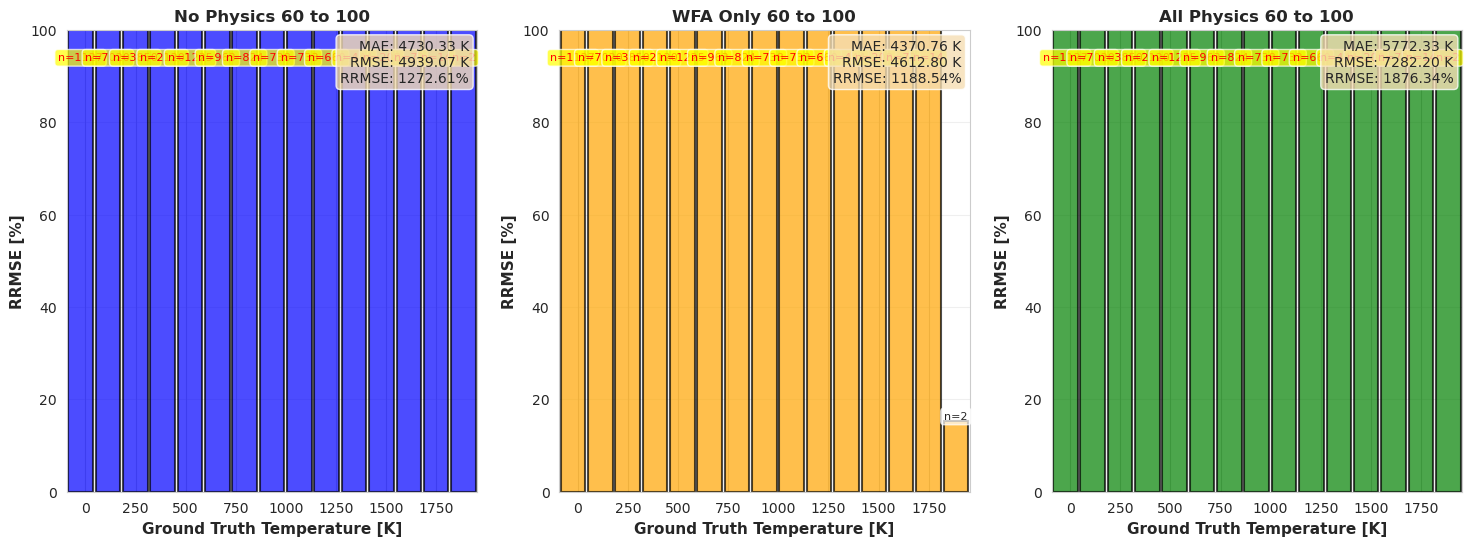

In [13]:
# Analyze how prediction errors depend on the magnitude of the parameter
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"error_analysis_{param}_logtau_{od_to_plot}.png"
        analysis.analyze_error_by_magnitude(
            all_predictions=all_predictions_region,
            ground_truth=region_data['spinor_atm'],
            mag_to_analyze=param,
            od_val=od_to_plot,
            logtau=logtau,
            n_bins=15,
            plot_counts=True,
            use_absolute=False,
            rrmse_ylim=(0, 100),
            save_dir=images_save_path,
            filename=filename
        )

### 7.5 Uncertainty Calibration

In [ ]:
# Verify that predicted uncertainties match actual errors
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        filename = f"uncertainty_vs_error_{param}_logtau_{od_to_plot}.png"
        analysis.plot_uncertainty_vs_error(
            all_predictions=all_predictions_region,
            ground_truth=region_data['spinor_atm'],
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            save_dir=images_save_path,
            filename=filename
        )

  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_T_logtau_-2.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_T_logtau_-0.8.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_T_logtau_0.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_Vz_logtau_-2.0.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_Vz_logtau_-0.8.json
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plag

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/uncertainty_vs_error/uncertainty_vs_error_Bz_logtau_0.0.json


### 7.6 Jointplot Statistical Analysis

In [ ]:
# Create jointplots for detailed statistical comparison
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        print(f"\n{'='*80}")
        print(f"Separate Jointplots: {param} (Region)")
        print(f"{'='*80}")
        filename_prefix = f"jointplot_{param}_logtau_{od_to_plot}"
        analysis.plot_jointplot_comparison(
            all_predictions=all_predictions_region,
            ground_truth=region_data['spinor_atm'],
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            n_samples=5000,
            kind='reg',
            save_dir=images_save_path,
            filename_prefix=filename_prefix
        )


Separate Jointplots: T (Region)


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_T_logtau_-2.0_no_physics.json

No Physics - Temperature at log(τ)=-2.0
  Pearson R:   -0.8187 (p=0.00e+00)
  RMSE:        4927.54 K
  Bias:        4252.32 K
  Samples:     5,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_T_logtau_-2.0_wfa_only.json

WFA Only - Temperature at log(τ)=-2.0
  Pearson R:   -0.8657 (p=0.00e+00)
  RMSE:        4615.82 K
  Bias:        3547.54 K
  Samples:     5,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_T_logtau_-2.0_all_physics.json

All Physics - Temperature at log(τ)=-2.0
  Pearson R:   -0.8707 (p=0.00e+00)
  RMSE:        7416.92 K
  Bias:        1059.47 K
  Samples:     5,000

Separate Jointplots: T (Re

/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/analysis_functions.py:1006: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_Bz_logtau_0.0_no_physics.json

No Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0741 (p=1.57e-07)
  RMSE:        inf G
  Bias:        1531679159080798126080.00 G
  Samples:     5,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_Bz_logtau_0.0_wfa_only.json

WFA Only - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0557 (p=8.19e-05)
  RMSE:        12828779.00 G
  Bias:        -304809.59 G
  Samples:     5,000
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/jointplot_comparison/jointplot_Bz_logtau_0.0_all_physics.json

All Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0614 (p=1.38e-05)
  RMSE:        493433189826560.

: 

In [ ]:
# Combined jointplot with all models overlaid
for param in ['T', 'Vz', 'Bz']:
    for od_to_plot in modest_logtau:
        print(f"\n{'='*80}")
        print(f"Combined Jointplot: {param} (Region)")
        print(f"{'='*80}")
        filename = f"combined_jointplot_{param}_logtau_{od_to_plot}.png"
        analysis.plot_combined_jointplot(
            all_predictions=all_predictions_region,
            ground_truth=region_data['spinor_atm'],
            mag_to_plot=param,
            od_val=od_to_plot,
            logtau=logtau,
            n_samples=3000,
            save_dir=images_save_path,
            filename=filename
        )


Combined Jointplot: T (Region)


  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/combined_jointplot/combined_jointplot_T_logtau_-2.0.json

Combined Analysis: Temperature at log(τ)=-2.0

No Physics:
  Pearson R:   -0.8144 (p=0.00e+00)
  RMSE:        4914.57 K
  Bias:        4264.78 K
  Samples:     3,000

WFA Only:
  Pearson R:   -0.8669 (p=0.00e+00)
  RMSE:        4577.46 K
  Bias:        3481.06 K
  Samples:     3,000

All Physics:
  Pearson R:   -0.8672 (p=0.00e+00)
  RMSE:        7305.91 K
  Bias:        1088.89 K
  Samples:     3,000

Combined Jointplot: T (Region)
  ✓ Metrics saved to /scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/images/modest_analysis/cut_region_plage/combined_jointplot/combined_jointplot_T_logtau_-0.8.json

Combined Analysis: Temperature at log(τ)=-0.8

No Physics:
  Pearson R:   -0.3839 (p=6.05e-106)
  RMSE:        987.20 K
  Bias:        -507.90 K
  Samples:     3,000

WFA Only:
  Pearson R:   -0.4169 (p=1.67e-126)
 

## 8. Region-Specific Statistics

Compute summary statistics for the extracted region.

In [ ]:
# Compute comprehensive statistics for the region
print("\n" + "="*80)
print(f"REGION SUMMARY STATISTICS")
print(f"Region: Y=[{y_start}:{y_end}], X=[{x_start}:{x_end}]")
print(f"Size: {H_region}×{W_region} pixels ({H_region*W_region:,} total)")
print("="*80)

for param in ['T', 'Vz', 'Bz']:
    print(f"\n{param}:")
    print("-"*80)
    
    gt_key = {'T': 'T', 'Vz': 'Vlos', 'Bz': 'Blos'}[param]
    
    for od_val in [-2.0, -0.8, 0.0]:
        if od_val in region_data['spinor_atm'][gt_key]:
            od_idx = np.argmin(np.abs(logtau - od_val))
            gt = region_data['spinor_atm'][gt_key][od_val]
            
            print(f"\n  log(τ) = {od_val:.1f}:")
            print(f"    Ground Truth:  mean={np.mean(gt):.2f}, std={np.std(gt):.2f}")
            
            for model_name, pred_data in all_predictions_region.items():
                pred_mean = pred_data['mean'][param][:, :, od_idx]
                pred_std_map = pred_data['std'][param][:, :, od_idx]
                
                diff = pred_mean - gt
                rmse = np.sqrt(np.mean(diff**2))
                bias = np.mean(diff)
                corr, _ = pearsonr(pred_mean.flatten(), gt.flatten())
                mean_uncertainty = np.mean(pred_std_map)
                
                print(f"    {pred_data['label']:15s}: "
                      f"R={corr:.3f}, RMSE={rmse:.2f}, "
                      f"Bias={bias:+.2f}, σ_pred={mean_uncertainty:.2f}")

print("\n" + "="*80)


REGION SUMMARY STATISTICS
Region: Y=[200:300], X=[300:400]
Size: 100×100 pixels (10,000 total)

T:
--------------------------------------------------------------------------------

  log(τ) = -2.0:
    Ground Truth:  mean=2039.90, std=531.37
    No Physics     : R=-0.066, RMSE=2621.66, Bias=+1656.66, σ_pred=988.33
    WFA Only       : R=-0.320, RMSE=1847.67, Bias=+430.02, σ_pred=404.91
    All Physics    : R=-0.115, RMSE=2075.02, Bias=+1699.79, σ_pred=248.85

  log(τ) = -0.8:
    Ground Truth:  mean=4424.90, std=604.95
    No Physics     : R=-0.309, RMSE=1430.18, Bias=-722.47, σ_pred=394.24
    WFA Only       : R=0.081, RMSE=723.81, Bias=+366.82, σ_pred=143.88
    All Physics    : R=0.489, RMSE=863.41, Bias=+682.17, σ_pred=99.32

  log(τ) = 0.0:
    Ground Truth:  mean=5151.10, std=752.33
    No Physics     : R=0.375, RMSE=1798.68, Bias=+1486.13, σ_pred=603.89
    WFA Only       : R=0.309, RMSE=2694.05, Bias=+2523.48, σ_pred=270.39
    All Physics    : R=0.363, RMSE=1436.95, Bias=+122

/tmp/ipykernel_1438428/719994864.py:27: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(diff**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


## 9. Save Results (Optional)

Save the predictions and analysis for the region.

In [ ]:
# Optional: Save region predictions
output_dir = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/region_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

region_name = f"region_y{y_start}-{y_end}_x{x_start}-{x_end}"

for model_name, pred_data in all_predictions_region.items():
    model_output_dir = output_dir / model_name / region_name
    model_output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save predictions as numpy arrays
    for param in ['T', 'Vz', 'Bz']:
        np.save(model_output_dir / f"{param}_mean.npy", pred_data['mean'][param])
        np.save(model_output_dir / f"{param}_std.npy", pred_data['std'][param])
    
    print(f"✓ Saved predictions for {pred_data['label']} to {model_output_dir}")

print(f"\n✓ All region predictions saved to {output_dir}")

## 10. Conclusions

This notebook demonstrates how to:
1. Extract a spatial region from MODEST data using `ModestData.extract_region()`
2. Apply trained models to smaller regions for focused analysis
3. Use the same comprehensive analysis tools as notebook 8
4. Compare model performance on specific features

The smaller region allows for:
- **Faster computation**: Fewer pixels to process
- **Detailed analysis**: Better visualization of spatial structures
- **Feature-specific insights**: Focus on sunspots, plage, or quiet sun
- **Resource efficiency**: Can analyze multiple regions without overwhelming memory